In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('sales_data.csv')

In [3]:
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David


In [4]:
# showing the row and columns in dataset
print(f'Rows Of Data {df.shape[0]}')
print(f'Columns Of Data {df.shape[1]}')

Rows Of Data 1000
Columns Of Data 14


In [66]:
# Get basic information about the dataset
# Shows: column names, non-null counts, data types, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

In [67]:
# Check for duplicate rows in the dataset
print(f'The number of duplictes {df.duplicated().sum()}')

The number of duplictes 0


In [68]:
# Check for missing values in each column
df.isna().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [69]:
# Display number of unique values in each column
df.nunique()

Product_ID               100
Sale_Date                340
Sales_Rep                  5
Region                     4
Sales_Amount             998
Quantity_Sold             49
Product_Category           4
Unit_Cost                998
Unit_Price              1000
Customer_Type              2
Discount                  31
Payment_Method             3
Sales_Channel              2
Region_and_Sales_Rep      20
dtype: int64

In [70]:
# Descriptive statistics for numerical columns
df.describe()

,Product_ID,Sale_Date,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,2023-07-02 17:42:43.199999744,5019.265230,25.355000,2475.304550,2728.440120,0.15239
min,1001.000000,2023-01-01 00:00:00,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2023-03-30 00:00:00,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,2023-06-30 12:00:00,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,2023-10-12 00:00:00,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,2024-01-01 00:00:00,9989.040000,49.000000,4995.300000,5442.150000,0.30000
std,29.573505,NaN,2846.790126,14.159006,1417.872546,1419.399839,0.08720


In [71]:
# Splitting date columns (actually splitting numerical and string columns) 
num_df = df.select_dtypes(include='number')
str_df = df.select_dtypes(include='object')

In [72]:
num_df

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
0,1052,5053.97,18,152.75,267.22,0.09
1,1093,4384.02,17,3816.39,4209.44,0.11
2,1015,4631.23,30,261.56,371.40,0.20
3,1072,2167.94,39,4330.03,4467.75,0.02
4,1061,3750.20,13,637.37,692.71,0.08
...,...,...,...,...,...,...
995,1010,4733.88,4,4943.03,5442.15,0.29
996,1067,4716.36,37,1754.32,1856.40,0.21
997,1018,7629.70,17,355.72,438.27,0.06
998,1100,1629.47,39,3685.03,3743.39,0.01


In [73]:
# string columns 
str_df

,Sales_Rep,Region,Product_Category,Customer_Type,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,Bob,North,Furniture,Returning,Cash,Online,North-Bob
1,Bob,West,Furniture,Returning,Cash,Retail,West-Bob
2,David,South,Food,Returning,Bank Transfer,Retail,South-David
3,Bob,South,Clothing,New,Credit Card,Retail,South-Bob
4,Charlie,East,Electronics,New,Credit Card,Online,East-Charlie
...,...,...,...,...,...,...,...
995,Charlie,North,Food,Returning,Cash,Online,North-Charlie
996,Bob,North,Clothing,New,Bank Transfer,Retail,North-Bob
997,David,South,Clothing,Returning,Bank Transfer,Online,South-David
998,David,West,Electronics,New,Bank Transfer,Online,West-David


In [13]:
# converting in date time
df['Sale_Date']  = pd.to_datetime(df['Sale_Date'])

In [14]:
# Function to count outliers in each column
def count_outliers_iqr(df):
    outlier_counts = {}
    
    
    for col in num_df:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_counts[col] = len(outliers)
    
    return pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])

# Display outlier counts
outlier_summary = count_outliers_iqr(df)
print(outlier_summary)

               Outlier_Count
Product_ID                 0
Sales_Amount               0
Quantity_Sold              0
Unit_Cost                  0
Unit_Price                 0
Discount                   0


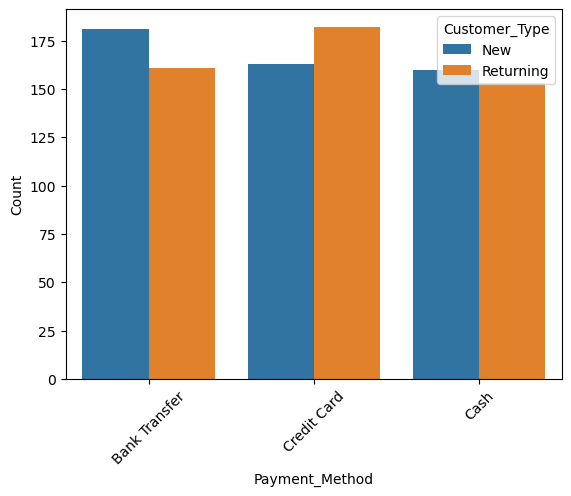

In [74]:
# Use the payment preference data we already created
payment_prefs = df.groupby('Customer_Type')['Payment_Method'].value_counts().reset_index(name='Count')

# Plot payment method preferences by customer type
sns.barplot(data=payment_prefs, x='Payment_Method', y='Count', hue='Customer_Type')
plt.xticks(rotation=45)
plt.show()

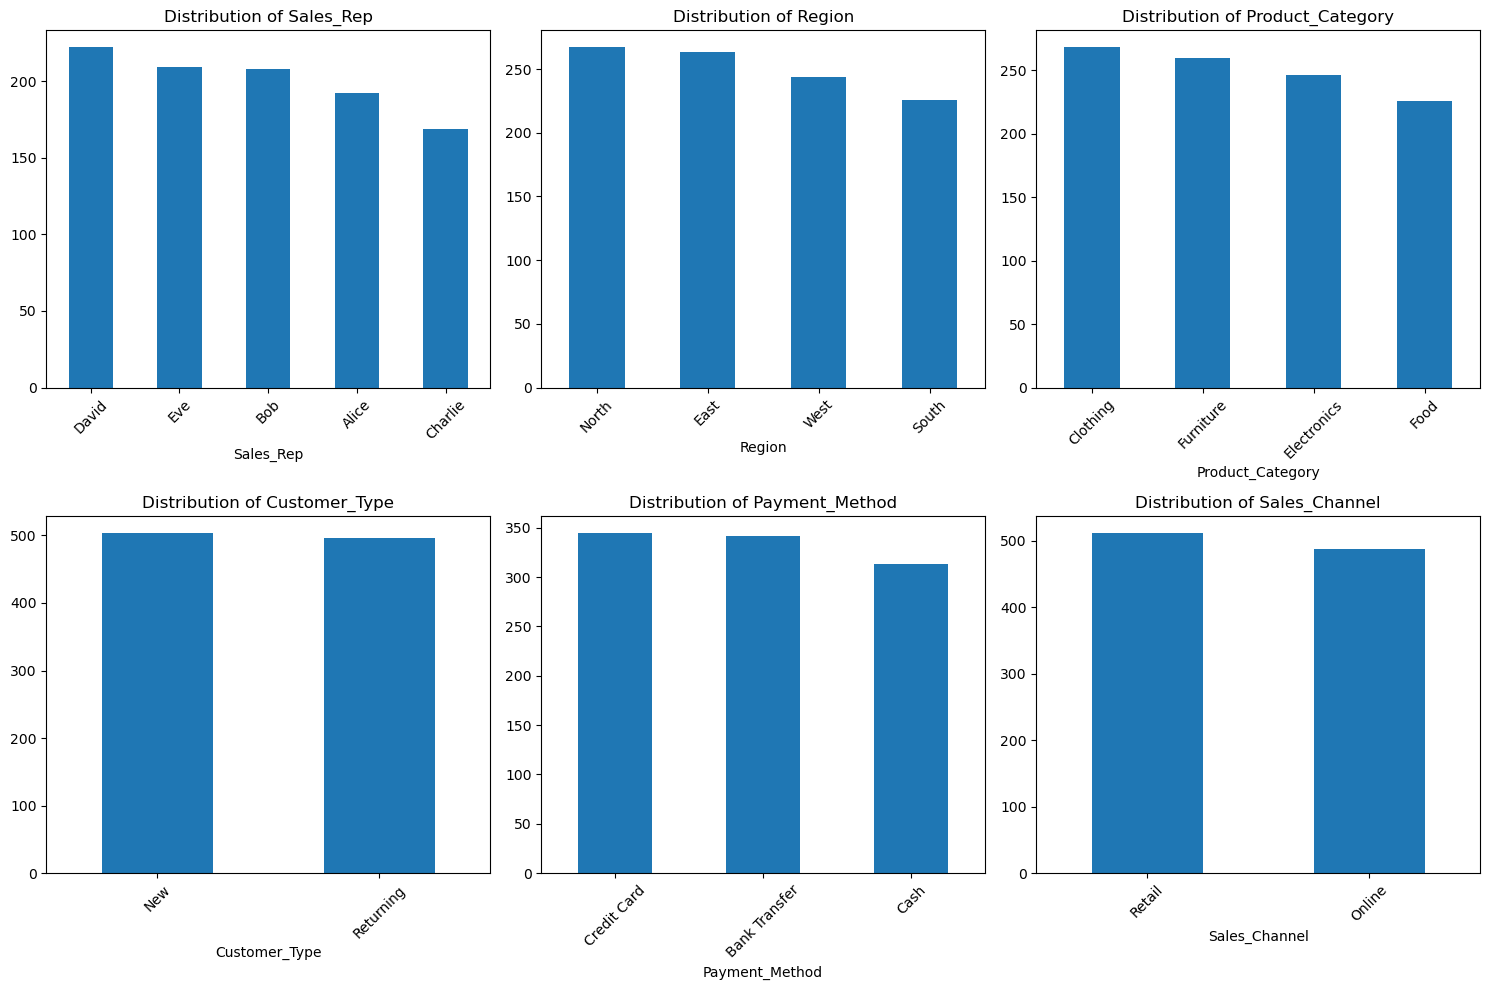

In [75]:
# Select the columns we want to visualize
columns_to_show = ['Sales_Rep', 'Region','Product_Category','Customer_Type','Payment_Method','Sales_Channel']

# Create subplots: 2 rows and 3 columns for 6 charts total
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows × 3 columns = 6 subplots
axes = axes.flatten()  # Convert 2D array to 1D for easier iteration

# Generate a bar chart for each selected column
for i, column in enumerate(columns_to_show):
    df[column].value_counts().plot(kind='bar', ax=axes[i], title=f'Distribution of {column}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels to prevent overlap

# Automatically adjust spacing between subplots
plt.tight_layout()
plt.show()

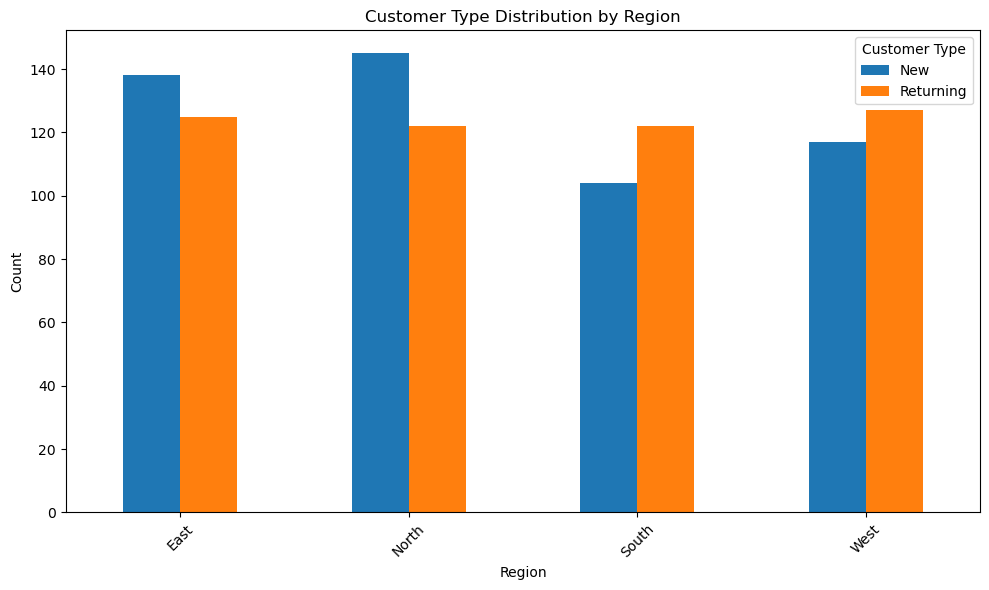

In [76]:
# Which region has the most returning customers
region_cus = df.groupby('Region')['Customer_Type'].value_counts().unstack()

# Plot as stacked bar chart
region_cus.plot(kind='bar', figsize=(10, 6))
plt.title('Customer Type Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.legend(title='Customer Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

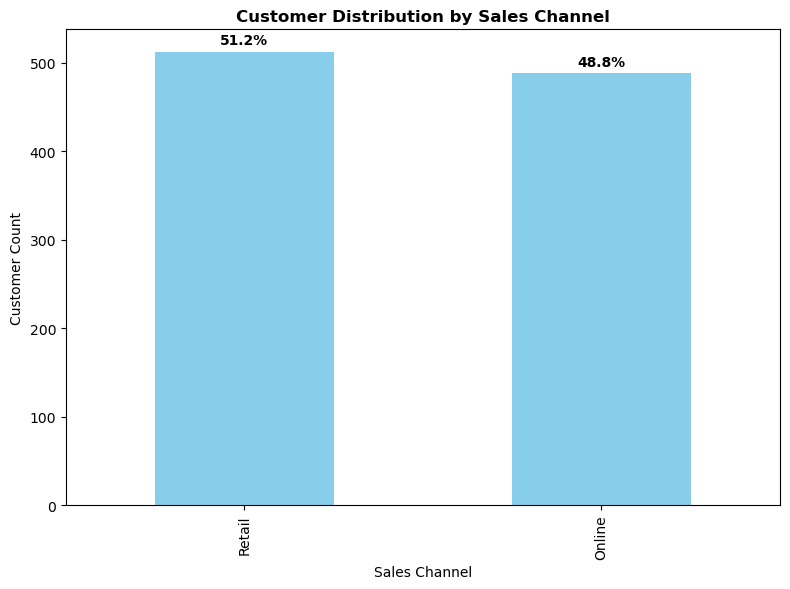

In [77]:
# Find which sales channel brings the most customers
coming_cus = df['Sales_Channel'].value_counts()
total = len(df)

# Create bar chart
ax = coming_cus.plot(kind='bar', figsize=(8,6), color='skyblue')

# Add percentage labels on top of each bar
for i, v in enumerate(coming_cus.values):
    percentage = f'{v/total*100:.1f}%'
    ax.text(i, v + (v*0.01), percentage, ha='center', va='bottom', fontweight='bold')

# Customize chart labels and title
plt.xlabel('Sales Channel')
plt.ylabel('Customer Count')
plt.title('Customer Distribution by Sales Channel', fontweight='bold')
plt.tight_layout()
plt.show()


In [62]:
# which product has the highest customer count
top_product = df['Product_Category'].value_counts().head(1)
print(f"Product with most customers: {top_product.index[0]} with {top_product.values[0]} customers")

Product with most customers: Clothing with 268 customers
